<a href="https://colab.research.google.com/github/mindioanni/LandLevelTools/blob/main/Seismicity_V6_08022025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build the environment

In [1]:
!apt-get install -qq gmt

Selecting previously unselected package gmt-common.
(Reading database ... 124926 files and directories currently installed.)
Preparing to unpack .../0-gmt-common_6.4.0+dfsg-2~jammy0_all.deb ...
Unpacking gmt-common (6.4.0+dfsg-2~jammy0) ...
Selecting previously unselected package libfftw3-single3:amd64.
Preparing to unpack .../1-libfftw3-single3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-single3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package libgmt6:amd64.
Preparing to unpack .../2-libgmt6_6.4.0+dfsg-2~jammy0_amd64.deb ...
Unpacking libgmt6:amd64 (6.4.0+dfsg-2~jammy0) ...
Selecting previously unselected package gmt.
Preparing to unpack .../3-gmt_6.4.0+dfsg-2~jammy0_amd64.deb ...
Unpacking gmt (6.4.0+dfsg-2~jammy0) ...
Selecting previously unselected package gmt-dcw.
Preparing to unpack .../4-gmt-dcw_2.1.0-1_all.deb ...
Unpacking gmt-dcw (2.1.0-1) ...
Selecting previously unselected package gmt-gshhg-high.
Preparing to unpack .../5-gmt-gshhg-high_2.3.7-5_all.deb

In [2]:
!apt-get install -qq libgmt-dev # Install the GMT library development package

Selecting previously unselected package libgmt-dev.
(Reading database ... 125269 files and directories currently installed.)
Preparing to unpack .../libgmt-dev_6.4.0+dfsg-2~jammy0_amd64.deb ...
Unpacking libgmt-dev (6.4.0+dfsg-2~jammy0) ...
Setting up libgmt-dev (6.4.0+dfsg-2~jammy0) ...
Processing triggers for man-db (2.10.2-1) ...


In [3]:
!pip install pygmt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.1 MB/s eta 0:00:00


In [4]:
!gmt --version

6.4.0


In [5]:
import pygmt
print(pygmt.show_versions())

PyGMT information:
  version: v0.14.1
System information:
  python: 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
  executable: /usr/bin/python3
  machine: Linux-6.1.85+-x86_64-with-glibc2.35
Dependency information:
  numpy: 1.26.4
  pandas: 2.2.2
  xarray: 2025.1.2
  netCDF4: 1.7.2
  packaging: 24.2
  contextily: None
  geopandas: 1.0.1
  IPython: 7.34.0
  pyarrow: 17.0.0
  rioxarray: None
  gdal: 3.6.4
  ghostscript: None
GMT library information:
  version: 6.4.0
  padding: 2
  share dir: /usr/share/gmt
  plugin dir: /usr/lib/x86_64-linux-gnu/gmt/plugins
  library path: /usr/lib/x86_64-linux-gnu/libgmt.so
  cores: 2
  grid layout: rows
  image layout: 
  binary version: 6.4.0
  Ghostscript is not detected. Your installation may be broken.
None


In [6]:
!pip install geopandas contextily


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 26.2 MB/s eta 0:00:00


In [7]:
import geopandas as gpd
print(gpd.show_versions())


SYSTEM INFO
-----------
python     : 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
executable : /usr/bin/python3
machine    : Linux-6.1.85+-x86_64-with-glibc2.35

GEOS, GDAL, PROJ INFO
---------------------
GEOS       : 3.11.4
GEOS lib   : None
GDAL       : 3.9.1
GDAL data dir: /usr/local/lib/python3.11/dist-packages/pyogrio/gdal_data/
PROJ       : 9.4.1
PROJ data dir: /usr/local/lib/python3.11/dist-packages/pyproj/proj_dir/share/proj

PYTHON DEPENDENCIES
-------------------
geopandas  : 1.0.1
numpy      : 1.26.4
pandas     : 2.2.2
pyproj     : 3.7.0
shapely    : 2.0.7
pyogrio    : 0.10.0
geoalchemy2: None
geopy      : 2.4.1
matplotlib : 3.10.0
mapclassify: None
fiona      : None
psycopg    : None
psycopg2   : 2.9.10 (dt dec pq3 ext lo64)
pyarrow    : 17.0.0
None


In [8]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 67.1 MB/s eta 0:00:00


In [9]:
import os
from IPython import get_ipython
from IPython.core.magic import register_cell_magic
from IPython.display import display, HTML
from IPython.utils.capture import capture_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
from scipy.stats import gaussian_kde
import seaborn as sns
import folium
from folium.plugins import HeatMap
from google.colab import files
from scipy.stats import linregress
import requests
import zipfile
import os
from shapely.geometry import Point, LineString, box
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import cartopy.geodesic as gd
from scipy.ndimage import gaussian_filter1d


Build the logging/report routine

In [10]:
# Define the path for the HTML output
html_file_path = "/content/report_log.html"  # Αποθηκεύεται στο Google Colab

# Δημιουργία ή καθαρισμός του HTML αρχείου
with open(html_file_path, "w", encoding='utf-8') as file:
    file.write("<html><head><title>Seismic Report</title></head><body>")
    file.write("<h1>Seismic Report</h1><hr>")

@register_cell_magic
def capture_and_save_html(line, cell):
    """Capture cell execution and append outputs and plots to an HTML file."""
    ipython = get_ipython()

    # Run the cell and capture outputs
    with capture_output() as captured:
        ipython.run_cell(cell)

    # Display captured outputs in the notebook
    if captured.stdout:
        print(captured.stdout)
    if captured.stderr:
        print(captured.stderr)

    for output in captured.outputs:
        if 'data' in dir(output) and 'image/png' in output.data:
            display(HTML(f"<img src='data:image/png;base64,{output.data['image/png']}'/>"))
        if 'text' in dir(output):
            print(output.text)

    # Append captured outputs to an HTML file
    html_content = "<div style='margin:10px 0; padding:10px; border:1px solid #ccc;'>"

    if captured.stdout:
        html_content += f"<pre>{captured.stdout}</pre>"
    if captured.stderr:
        html_content += f"<pre style='color: red;'>{captured.stderr}</pre>"

    for output in captured.outputs:
        if 'data' in dir(output) and 'image/png' in output.data:
            img_html = f"<img src='data:image/png;base64,{output.data['image/png']}'/>"
            html_content += f"<div>{img_html}</div>"
        if 'text' in dir(output):
            html_content += f"<pre>{output.text}</pre>"

    html_content += "</div>"

    # Καταγραφή στο αρχείο
    with open(html_file_path, "a", encoding='utf-8') as file:
        file.write(html_content)


Import long term and short term time series

In [11]:

# ======= Φόρτωση αρχείων =======
print("Ανεβάστε το αρχείο μακροχρόνιων παρατηρήσεων - τελευταία έτη")
uploaded_10yrs = files.upload()
catalogue_10yrs = list(uploaded_10yrs.keys())[0]
print("\nΑνεβάστε το αρχείο βραχυχρόνιων παρατηρήσεων - τελευταίες εβδομάδες")
uploaded_35day = files.upload()
catalogue_35day = list(uploaded_35day.keys())[0]

Ανεβάστε το αρχείο μακροχρόνιων παρατηρήσεων - τελευταία έτη


Saving catalogue_long.csv to catalogue_long.csv

Ανεβάστε το αρχείο βραχυχρόνιων παρατηρήσεων - τελευταίες εβδομάδες


Saving catalogue_08022025.csv to catalogue_08022025.csv


Download coastlines

In [12]:
%%capture_and_save_html

import os
import requests
import zipfile
import geopandas as gpd

print(f"**INITIALIZING THE REPORT LOGGING**")
print("\n")
print(f"**Εnvironment already built**")
print("\n")
print(f"**Timeseries already uploaded on system**")
print("\n")
print(f"**Download coastlines and data**")
print("\n")

# ✅ Δημιουργία long-term dataframe
df_10yrs = pd.read_csv(catalogue_10yrs, parse_dates=["Origin Time (GMT)"])
df_10yrs = df_10yrs.sort_values(by="Origin Time (GMT)", ascending=True)
df_10yrs["Seismic Energy"] = 10 ** (5.24 + 1.44 * df_10yrs["Magnitude (ML)"])
df_10yrs["Cumulative Energy"] = df_10yrs["Seismic Energy"].cumsum()

# ✅ Εκτύπωση πληροφοριών για το long-term dataframe
print(f"\n**Long-term DataFrame (df_10yrs) created from file: {catalogue_10yrs}**")
print("\nFirst 5 rows:")
print(df_10yrs.head())
print("\nStatistics:")
print(df_10yrs.describe())
print(f"\nNumber of records: {len(df_10yrs)}")


# ✅ Δημιουργία short-term dataframe
df_35day = pd.read_csv(catalogue_35day, parse_dates=["Origin Time (GMT)"])
df_35day = df_35day.sort_values(by="Origin Time (GMT)", ascending=True)
df_35day["Seismic Energy"] = 10 ** (5.24 + 1.44 * df_35day["Magnitude (ML)"])
df_35day["Cumulative Energy"] = df_35day["Seismic Energy"].cumsum()

# ✅ Εκτύπωση πληροφοριών για το short-term dataframe
print(f"\n**Short-term DataFrame (df_35day) created from file: {catalogue_35day}**")
print("\nFirst 5 rows:")
print(df_35day.head())
print("\nStatistics:")
print(df_35day.describe())
print(f"\nNumber of records: {len(df_35day)}")


# ======= ✅ Κατέβασμα και αποσυμπίεση GSHHG ακτογραμμής (Fine resolution) =======

# ✅ Ορισμός εναλλακτικού URL λήψης
gshhg_url = "https://www.soest.hawaii.edu/pwessel/gshhg/gshhg-shp-2.3.7.zip"
gshhg_zip = "/content/gshhg-shapefiles.zip"
gshhg_dir = "/content/gshhg"

# ✅ Διαγραφή προηγούμενων αρχείων αν υπάρχουν
if os.path.exists(gshhg_zip):
    os.remove(gshhg_zip)
    print("📌 Προηγούμενο αρχείο ZIP διαγράφηκε.")

# ✅ Κατέβασμα του GSHHG shapefile
print("📥 Κατεβάζουμε το GSHHG shapefile από εναλλακτική πηγή...")
response = requests.get(gshhg_url, stream=True)

if response.status_code == 200:
    with open(gshhg_zip, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("✅ Η λήψη του αρχείου ολοκληρώθηκε.")
else:
    raise ConnectionError(f"❌ Αποτυχία λήψης. Status Code: {response.status_code}")

# ✅ Έλεγχος εγκυρότητας του ZIP
if zipfile.is_zipfile(gshhg_zip):
    print("✔️ Το αρχείο είναι έγκυρο ZIP.")
else:
    raise ValueError("❌ Το αρχείο δεν είναι έγκυρο ZIP. Δοκίμασε ξανά.")

# ✅ Αποσυμπίεση αρχείου
if not os.path.exists(gshhg_dir):
    os.makedirs(gshhg_dir)

print("📂 Αποσυμπίεση των GSHHG δεδομένων...")
with zipfile.ZipFile(gshhg_zip, "r") as zip_ref:
    zip_ref.extractall(gshhg_dir)
print("✅ Η αποσυμπίεση ολοκληρώθηκε.")

# ✅ Εντοπισμός του shapefile υψηλής ανάλυσης
coastline_shp = None
for root, dirs, files in os.walk(gshhg_dir):
    for file in files:
        if file.endswith("GSHHS_f_L1.shp"):  # Χρήση ακτογραμμής υψηλής ανάλυσης
            coastline_shp = os.path.join(root, file)
            print(f"🌍 Βρέθηκε το shapefile ακτογραμμής: {coastline_shp}")

# ✅ Φόρτωση των δεδομένων ακτογραμμής
if coastline_shp:
    coastline = gpd.read_file(coastline_shp)
    print("✔️ Τα δεδομένα ακτογραμμής φορτώθηκαν επιτυχώς!")
else:
    raise FileNotFoundError("❌ Δεν βρέθηκε το GSHHS_f_L1.shp μετά την αποσυμπίεση.")

# ✅ Προβολή πρώτων γραμμών για επιβεβαίωση
print(coastline.head())

# ======= ✅ Κατέβασμα του αρχείου ρηγμάτων NOA faults (Fine resolution) =======
# Ορισμός του URL και του ονόματος αποθήκευσης
faults_url = "https://noa-beyondapps.maps.arcgis.com/sharing/rest/content/items/018068b94b41401a910237865776f4d7/data"
faults_csv_path = "/content/NOAFaults_v6.0.gmt.csv"

# Λήψη του αρχείου
response = requests.get(faults_url)

# Έλεγχος αν η λήψη ήταν επιτυχής
if response.status_code == 200:
    with open(faults_csv_path, "wb") as f:
        f.write(response.content)
    print(f"✅ Αντλήθηκε ο κατάλογος ρηγμάτων ΝΟΑFaults")
    print(f"✅ Το αρχείο αποθηκεύτηκε στο {faults_csv_path}")
else:
    print(f"❌ Αποτυχία λήψης του αρχείου. Status code: {response.status_code}")



**INITIALIZING THE REPORT LOGGING**


**Εnvironment already built**


**Timeseries already uploaded on system**


**Download coastlines and data**



**Long-term DataFrame (df_10yrs) created from file: catalogue_long.csv**

First 5 rows:
       Origin Time (GMT)  Latitude  Longitude  Depth (km)  Magnitude (ML)  \
2421 1966-03-08 20:29:37      36.7      25.70          10             3.7   
2420 1966-08-18 22:09:38      36.4      26.20         100             4.0   
2419 1967-09-16 21:32:24      36.5      26.25          10             3.5   
2418 1968-01-27 20:52:41      36.3      25.50          10             3.6   
2417 1968-04-08 13:00:42      36.8      25.70          10             4.1   

                  Location  Seismic Energy  Cumulative Energy  
2421   39.5 km NE of Thira    3.698282e+10       3.698282e+10  
2420    68.6 km E of Thira    1.000000e+11       1.369828e+11  
2419    73.6 km E of Thira    1.905461e+10       1.560374e+11  
2418  14.3 km SSE of Thira    2.654606e+10 



**Short Term Seismicity**

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)




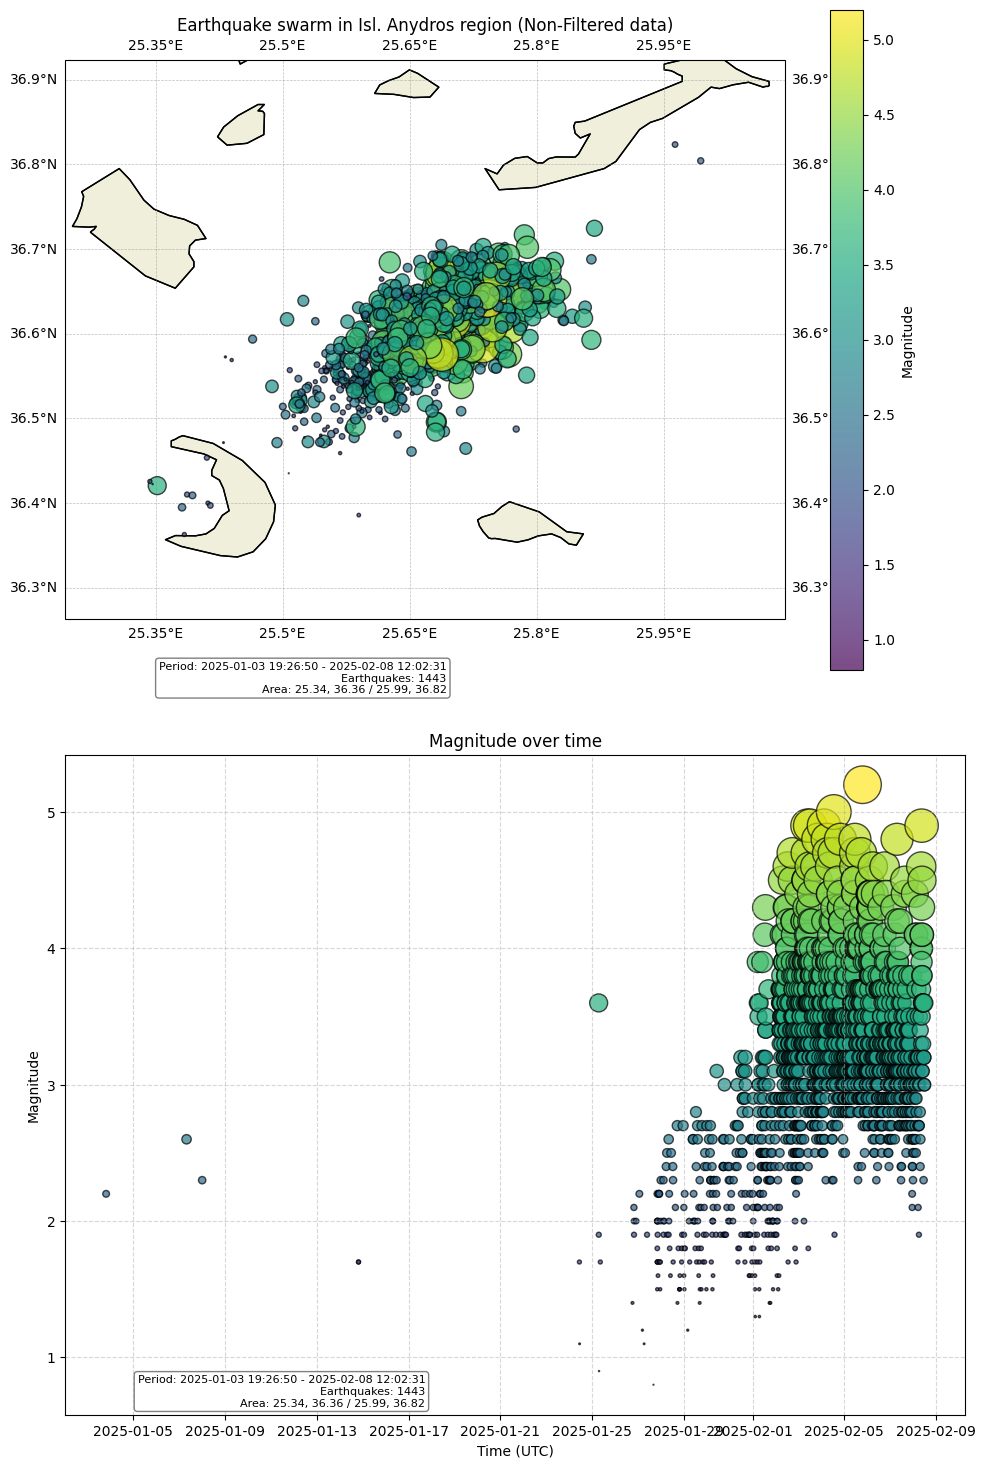

In [13]:
%%capture_and_save_html

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("\n")
print(f"**Short Term Seismicity**")

# ======= Έλεγχος δεδομένων =======
if 'Magnitude (ML)' not in df_35day.columns:
    raise KeyError("Το DataFrame δεν περιέχει στήλη με όνομα 'Magnitude (ML)'.")

# ======= Υπολογισμός γεωγραφικών ορίων =======
expansion_factor = 0.1  # Επέκταση ορίων για καλύτερη απεικόνιση
lon_min, lon_max = df_35day['Longitude'].min() - expansion_factor, df_35day['Longitude'].max() + expansion_factor
lat_min, lat_max = df_35day['Latitude'].min() - expansion_factor, df_35day['Latitude'].max() + expansion_factor

# ======= Ρυθμίσεις δεδομένων =======
df_filtered = df_35day[(df_35day['Longitude'] >= lon_min) & (df_35day['Longitude'] <= lon_max) &
                       (df_35day['Latitude'] >= lat_min) & (df_35day['Latitude'] <= lat_max)]

# Υπολογισμός περιόδου δεδομένων και αριθμού σεισμών
date_from = pd.to_datetime(df_35day['Origin Time (GMT)']).min().strftime('%Y-%m-%d %H:%M:%S')
date_to = pd.to_datetime(df_35day['Origin Time (GMT)']).max().strftime('%Y-%m-%d %H:%M:%S')
earthquake_count = len(df_35day)

lons_min, lons_max = df_35day["Longitude"].min(), df_35day["Longitude"].max()
lats_min, lats_max = df_35day["Latitude"].min(), df_35day["Latitude"].max()

# ======= Δημιουργία Χάρτη =======
fig = plt.figure(figsize=(10, 15))

# Υποχάρτης: Γεωγραφικός Χάρτης
ax_map = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax_map.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Προσθήκη χαρακτηριστικών στον χάρτη
ax_map.add_feature(cfeature.LAND, edgecolor='black', zorder=0)
ax_map.add_feature(cfeature.COASTLINE, zorder=1)
ax_map.add_feature(cfeature.BORDERS, linestyle=':', zorder=1)
ax_map.add_feature(cfeature.LAKES, color='lightblue', zorder=0)
ax_map.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Σχεδίαση σεισμών
sc = ax_map.scatter(df_35day['Longitude'], df_filtered['Latitude'],
                    c=df_35day['Magnitude (ML)'], s=df_35day['Magnitude (ML)'] ** 4,  # Το μέγεθος εξαρτάται από τον σεισμό
                    cmap='viridis', alpha=0.7, edgecolor='k', transform=ccrs.PlateCarree(), zorder=2)
plt.colorbar(sc, ax=ax_map, label='Magnitude', orientation='vertical')

# Προσθήκη σημειώσεων
ax_map.set_title("Earthquake swarm in Isl. Anydros region (Non-Filtered data)")

# Προσθήκη υπομνήματος κάτω δεξιά
ax_map.text(
    lon_max - 0.4, lat_min - 0.05,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='top', bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

# ======= Υποχάρτης: Χρονική εξέλιξη =======
ax_time = fig.add_subplot(2, 1, 2)
ax_time.scatter(df_35day['Origin Time (GMT)'], df_35day['Magnitude (ML)'],
                c=df_35day['Magnitude (ML)'], cmap='viridis',
                s=df_35day['Magnitude (ML)'] ** 4, alpha=0.7, edgecolor='k')
ax_time.set_xlabel("Time (UTC)")
ax_time.set_ylabel("Magnitude")
ax_time.grid(True, linestyle='--', alpha=0.5)
ax_time.set_title("Magnitude over time")

# Προσθήκη υπομνήματος κάτω δεξιά
ax_time.text(
    0.4, 0.01,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=ax_time.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

# ======= Εμφάνιση Χάρτη =======
plt.tight_layout()
plt.show()


Εφαρμογή επιθυμητού εύρους τιμών Μ

In [14]:
%%capture_and_save_html

print("\n")
print(f"**Apply window for data**")

# ======= Ερώτημα προς τον χρήστη =======
while True:
    user_choice = input("Θέλεις να φιλτραριστούν οι σεισμοί σε συγκεκριμένο εύρος τιμών Μ; (Yes/No): ").strip().lower()
    if user_choice in ["yes", "no"]:
        break
    print("Παρακαλώ απάντησε με Yes ή No.")

if user_choice == "yes":
    while True:
        try:
            min_magnitude = float(input("Δώσε ελάχιστο Μ: ").strip())
            max_magnitude = float(input("Δώσε μέγιστο Μ: ").strip())

            if min_magnitude > max_magnitude:
                print("Το ελάχιστο Μ πρέπει να είναι μικρότερο ή ίσο με το μέγιστο Μ. Προσπάθησε ξανά.")
            else:
                break
        except ValueError:
            print("Παρακαλώ εισήγαγε αριθμητικές τιμές για τα μεγέθη Μ.")

    # ======= Φιλτράρισμα των σεισμών =======
    df_35day = df_35day[(df_35day["Magnitude (ML)"] >= min_magnitude) & (df_35day["Magnitude (ML)"] <= max_magnitude)]
    df_10yrs = df_10yrs[(df_10yrs["Magnitude (ML)"] >= min_magnitude) & (df_10yrs["Magnitude (ML)"] <= max_magnitude)]

    print(f"Έγινε φιλτράρισμα των σεισμών στο εύρος {min_magnitude} ≤ M ≤ {max_magnitude}")
else:
    print("Δεν εφαρμόστηκε φιλτράρισμα στα δεδομένα.")

print("\n")
print(f"**Στατιστικά στοιχεία του short-term dataframe μετά την εφαρμογή του φίλτρου**")


# ✅ Εκτύπωση πληροφοριών για το short-term dataframe μετά την εφαρμογή του φίλτρου
print(f"\n**Short-term DataFrame (df_35day) created from file: {catalogue_35day}**")
print("\nFirst 5 rows:")
print(df_35day.head())
print("\nStatistics:")
print(df_35day.describe())
print(f"\nNumber of records: {len(df_35day)}")


Θέλεις να φιλτραριστούν οι σεισμοί σε συγκεκριμένο εύρος τιμών Μ; (Yes/No): Yes
Δώσε ελάχιστο Μ: 3
Δώσε μέγιστο Μ: 9


**Apply window for data**
Έγινε φιλτράρισμα των σεισμών στο εύρος 3.0 ≤ M ≤ 9.0


**Στατιστικά στοιχεία του short-term dataframe μετά την εφαρμογή του φίλτρου**

**Short-term DataFrame (df_35day) created from file: catalogue_08022025.csv**

First 5 rows:
       Origin Time (GMT)  Latitude  Longitude  Depth (km)  Magnitude (ML)  \
1435 2025-01-25 06:57:24   36.4206    25.3519          11             3.6   
1304 2025-01-30 10:30:37   36.6170    25.5052           8             3.1   
1294 2025-01-30 18:37:13   36.5378    25.4874          15             3.0   
1274 2025-01-31 07:57:45   36.4728    25.5487          12             3.0   
1268 2025-01-31 11:53:54   36.5941    25.6197          12             3.2   

                  Location  Seismic Energy  Cumulative Energy  
1435     7.3 km W of Thira    2.654606e+10       2.827512e+10  
1304  23.2 km NNE of Thira    5.058

Run the code to create the graphs



**Gutenberg-Richter b value analysis - MLE and Least-Squares**






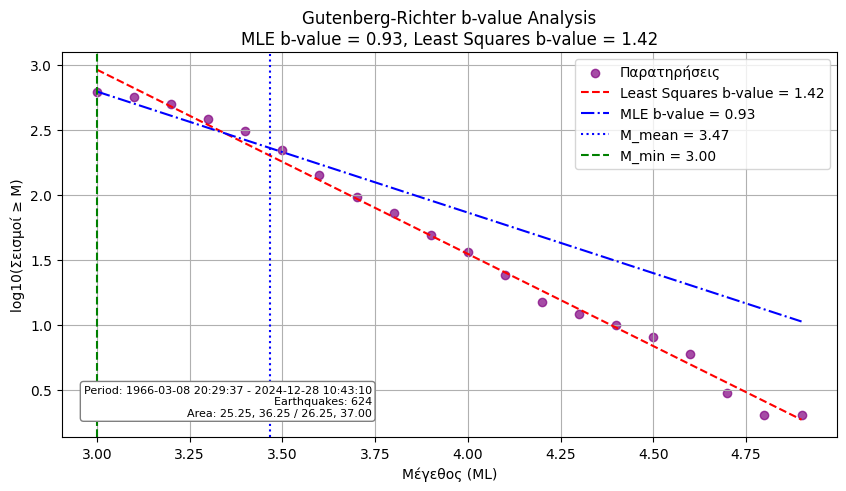

In [15]:
%%capture_and_save_html

print("\n")
print(f"**Gutenberg-Richter b value analysis - MLE and Least-Squares**")
print("\n")

# Append explanation to the HTML report with MathJax for LaTeX rendering
explanation_html = """
<div style="margin: 20px; padding: 10px; border: 1px solid #ccc; font-family: Arial, sans-serif;">
    <h3>Gutenberg-Richter <i>b-value</i> Analysis</h3>
    <p>The following code calculates the <b>b-value</b> using the <b>Maximum Likelihood Estimation (MLE)</b> method, as proposed by <b>Aki (1965)</b>:</p>
    <div style="background: #f9f9f9; padding: 10px; border: 1px solid #ddd; font-family: 'Courier New', monospace;">
        $$ b_{\\text{MLE}} = \\frac{\\log_{10} e}{M_{\\text{mean}} - M_{\\text{min}}} $$
    </div>
    <p>where:</p>
    <ul>
        <li><b>\( M_{\\text{mean}} \)</b> is the mean magnitude of the earthquakes in the sample,</li>
        <li><b>\( M_{\\text{min}} \)</b> is the minimum magnitude considered (due to completeness of data),</li>
        <li><b>\( \\log_{10} e \\approx 0.4343 \)</b> is the transformation from natural logarithms to base-10 logarithms.</li>
    </ul>
</div>
<script src="https://polyfill.io/v3/polyfill.min.js?features=es6"></script>
<script id="MathJax-script" async src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>
"""

# Save to the HTML report file
with open(html_file_path, "a", encoding='utf-8') as file:
    file.write(explanation_html)

# --- Gutenberg-Richter Ανάλυση (10 χρόνια) ---
magnitudes = df_10yrs["Magnitude (ML)"]

# Επιλογή του κατώτατου μεγέθους M_min (συνήθως το κατώτερο πλήρες μέγεθος των δεδομένων)
M_min = magnitudes.min()

# Υπολογισμός MLE b-value
M_mean = magnitudes.mean()
b_value_mle = np.log10(np.e) / (M_mean - M_min)

# --- Least Squares Fit (για σύγκριση) ---
bins = np.arange(M_min, magnitudes.max() + 0.1, 0.1)
counts, edges = np.histogram(magnitudes, bins=bins)
cumulative_counts = np.cumsum(counts[::-1])[::-1]

# Φιλτράρισμα για αποφυγή log(0)
valid_indices = cumulative_counts > 0
log_counts = np.log10(cumulative_counts[valid_indices])
log_mags = edges[:-1][valid_indices]

# Γραμμική παλινδρόμηση (Least Squares Fit)
slope, intercept, _, _, _ = linregress(log_mags, log_counts)
b_value_ls = -slope

# Υπολογισμός intercept για το MLE b-value
#mle_intercept = log_counts[0] - b_value_mle * log_mags[0]
mle_intercept = log_counts[0] + b_value_mle * log_mags[0]

# Υπολογισμός περιόδου δεδομένων, αριθμού γεγονότων, και γεωγραφικού εύρους
date_from = pd.to_datetime(df_10yrs['Origin Time (GMT)']).min().strftime('%Y-%m-%d %H:%M:%S')
date_to = pd.to_datetime(df_10yrs['Origin Time (GMT)']).max().strftime('%Y-%m-%d %H:%M:%S')
earthquake_count = len(df_10yrs)

lons_min, lons_max = df_10yrs["Longitude"].min(), df_10yrs["Longitude"].max()
lats_min, lats_max = df_10yrs["Latitude"].min(), df_10yrs["Latitude"].max()

# --- Σύγκριση των δύο μεθόδων ---
plt.figure(figsize=(10, 5))
plt.scatter(log_mags, log_counts, color='purple', alpha=0.7, label="Παρατηρήσεις")
plt.plot(log_mags, slope * log_mags + intercept, 'r--', label=f"Least Squares b-value = {b_value_ls:.2f}")
plt.plot(log_mags, -b_value_mle * log_mags + mle_intercept, 'b-.', label=f"MLE b-value = {b_value_mle:.2f}")

plt.axvline(M_mean, color='blue', linestyle=':', label=f"M_mean = {M_mean:.2f}")
plt.axvline(M_min, color='green', linestyle='--', label=f"M_min = {M_min:.2f}")

plt.xlabel("Μέγεθος (ML)")
plt.ylabel("log10(Σεισμοί ≥ M)")
plt.title(f"Gutenberg-Richter b-value Analysis\nMLE b-value = {b_value_mle:.2f}, Least Squares b-value = {b_value_ls:.2f}")
plt.legend()
plt.grid()

# Προσθήκη κουτιού με την περίοδο και αριθμό σεισμών
plt.text(
    0.4, 0.05,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)
plt.show()




**Time-series diagrams**




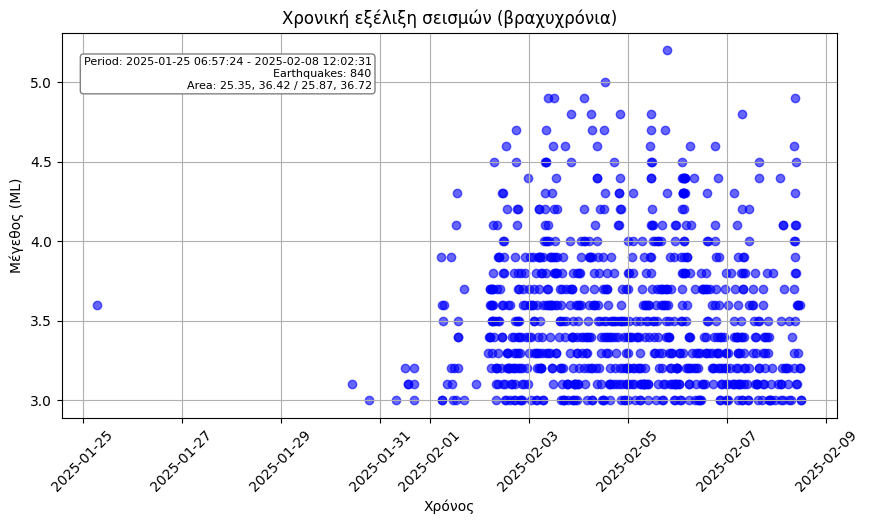


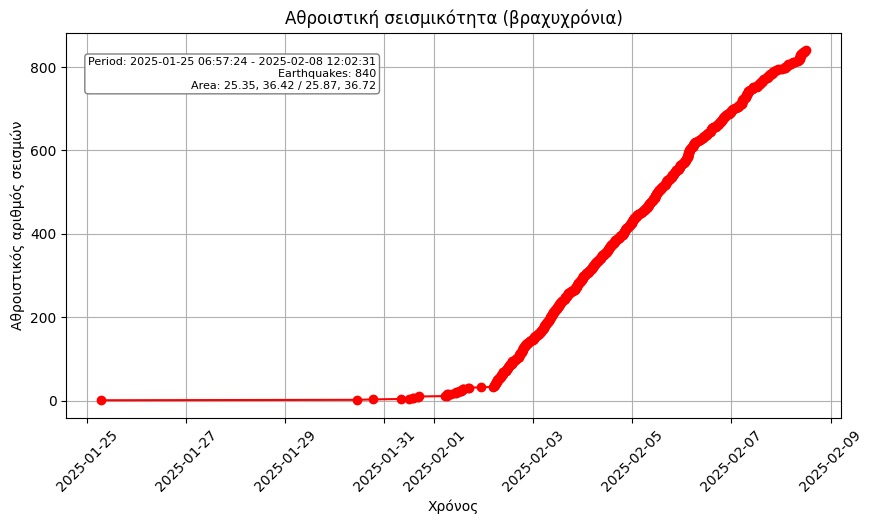


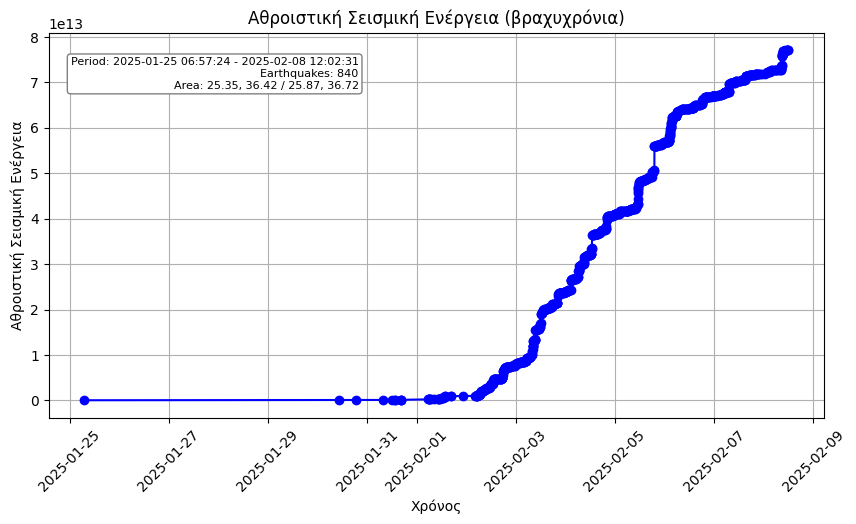


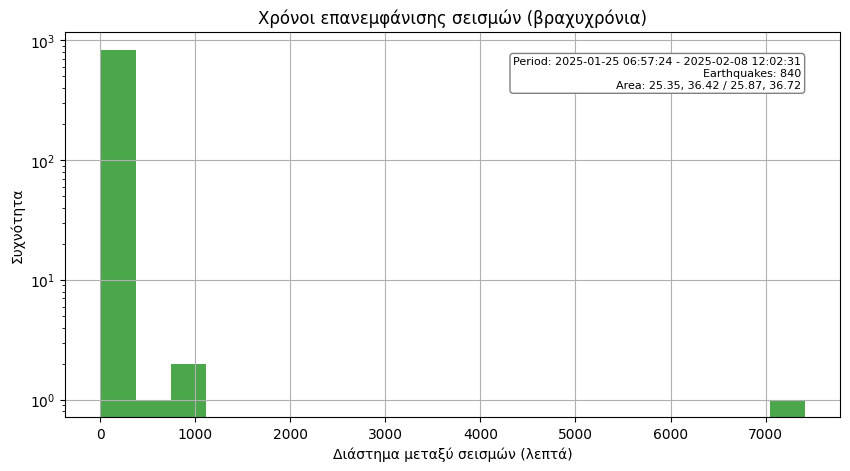


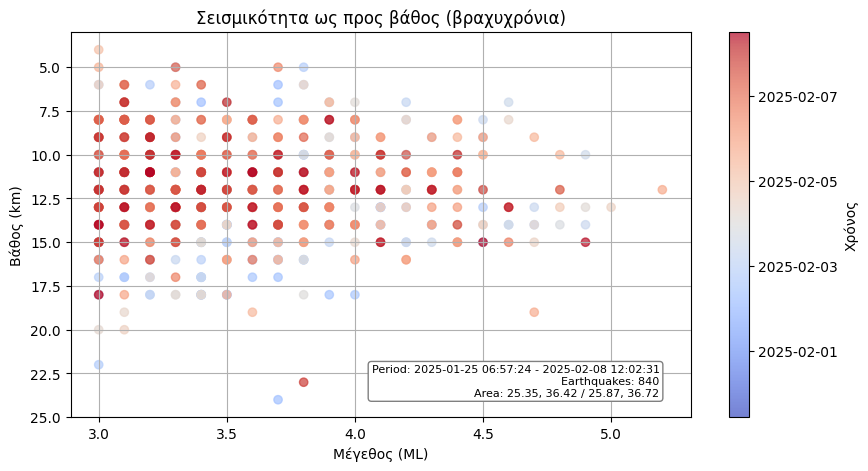

In [16]:
%%capture_and_save_html

print("\n")
print(f"**Time-series diagrams**")

# Υπολογισμός περιόδου δεδομένων και αριθμού σεισμών
date_from = pd.to_datetime(df_35day['Origin Time (GMT)']).min().strftime('%Y-%m-%d %H:%M:%S')
date_to = pd.to_datetime(df_35day['Origin Time (GMT)']).max().strftime('%Y-%m-%d %H:%M:%S')
earthquake_count = len(df_35day)

lons_min, lons_max = df_35day["Longitude"].min(), df_35day["Longitude"].max()
lats_min, lats_max = df_35day["Latitude"].min(), df_35day["Latitude"].max()


# --- Χρονική εξέλιξη σεισμών (35 ημέρες) ---
plt.figure(figsize=(10, 5))
plt.scatter(df_35day["Origin Time (GMT)"], df_35day["Magnitude (ML)"], c='b', alpha=0.6)
plt.xlabel("Χρόνος")
plt.ylabel("Μέγεθος (ML)")
plt.title("Χρονική εξέλιξη σεισμών (βραχυχρόνια)")
plt.xticks(rotation=45)
plt.grid()
plt.text(
    0.4, 0.85,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)
plt.show()

# --- Γράφημα Αθροιστικής Σεισμικότητας ---
df_35day["Cumulative Count"] = range(1, len(df_35day) + 1)
plt.figure(figsize=(10, 5))
plt.plot(df_35day["Origin Time (GMT)"], df_35day["Cumulative Count"], marker='o', linestyle='-', color='r')
plt.xlabel("Χρόνος")
plt.ylabel("Αθροιστικός αριθμός σεισμών")
plt.title("Αθροιστική σεισμικότητα (βραχυχρόνια)")
plt.xticks(rotation=45)
plt.grid()
plt.text(
    0.4, 0.85,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)
plt.show()

# --- Γράφημα Αθροιστικής Σεισμικής Ενέργειας ---
plt.figure(figsize=(10, 5))
plt.plot(df_35day["Origin Time (GMT)"], df_35day["Cumulative Energy"], marker='o', linestyle='-', color='b')
plt.xlabel("Χρόνος")
plt.ylabel("Αθροιστική Σεισμική Ενέργεια")
plt.title("Αθροιστική Σεισμική Ενέργεια (βραχυχρόνια)")
plt.xticks(rotation=45)
plt.grid()
plt.text(
    0.4, 0.85,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)
plt.show()

# --- Χρόνοι επανεμφάνισης σεισμών ---
df_35day["Interevent Time"] = df_35day["Origin Time (GMT)"].diff().dt.total_seconds() / 60  # σε λεπτά
df_35day = df_35day.dropna(subset=["Interevent Time"])  # Αφαιρεί την πρώτη NaN τιμή

plt.figure(figsize=(10, 5))
plt.hist(df_35day["Interevent Time"].dropna(), bins=20, color='g', alpha=0.7)
plt.xlabel("Διάστημα μεταξύ σεισμών (λεπτά)")
plt.ylabel("Συχνότητα")
plt.title("Χρόνοι επανεμφάνισης σεισμών (βραχυχρόνια)")
plt.yscale("log")  # Ορισμός λογαριθμικής κλίμακας στον άξονα y
plt.grid()
plt.text(
    0.95, 0.85,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)
plt.show()

# --- Σεισμικότητα vs. βάθος ---

# Μετατροπή των timestamps σε datetime
df_35day["Origin Time (GMT)"] = pd.to_datetime(df_35day["Origin Time (GMT)"], unit="s")

plt.figure(figsize=(10, 5))
sc = plt.scatter(df_35day["Magnitude (ML)"], df_35day["Depth (km)"],
                 c=df_35day["Origin Time (GMT)"].map(mdates.date2num),
                 cmap="coolwarm", alpha=0.7)

plt.xlabel("Μέγεθος (ML)")
plt.ylabel("Βάθος (km)")
plt.title("Σεισμικότητα ως προς βάθος (βραχυχρόνια)")

# Μετατροπή της χρωματικής κλίμακας σε μορφή ημερομηνίας
cbar = plt.colorbar(sc, label="Χρόνος")
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Μόνο ημερομηνία

plt.gca().invert_yaxis()  # Αν θέλεις το βάθος να ξεκινά από το 0 στην κορυφή
plt.grid()
plt.text(
    0.95, 0.05,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)
plt.show()


In [17]:
%%capture_and_save_html

print("\n")
print(f"**Series of folium maps**")

def create_heatmap(data, value_col, title):
    """Δημιουργεί heatmap για σεισμικότητα ή ενέργεια."""
    if data.empty:
        raise ValueError("Ο πίνακας δεδομένων είναι άδειος.")

    center_lat = data["Latitude"].mean()
    center_lon = data["Longitude"].mean()

    heat_data = data[["Latitude", "Longitude", value_col]].dropna().values.tolist()

    # Χρήση ESRI Satellite ως υπόβαθρο
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=9,
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri, Maxar, Earthstar Geographics"
    )

    HeatMap(heat_data, radius=10).add_to(m)
    return m



**Series of folium maps**



Enter bandwidth for KDE (0-1, 'scott', or 'silverman'): scott
Enter Gaussian smoothing radius in km (e.g., 0.5 - 20): 1.5


**Seismic Energy Density (Grid-based & KDE-based) with Clipped NOA Faults**




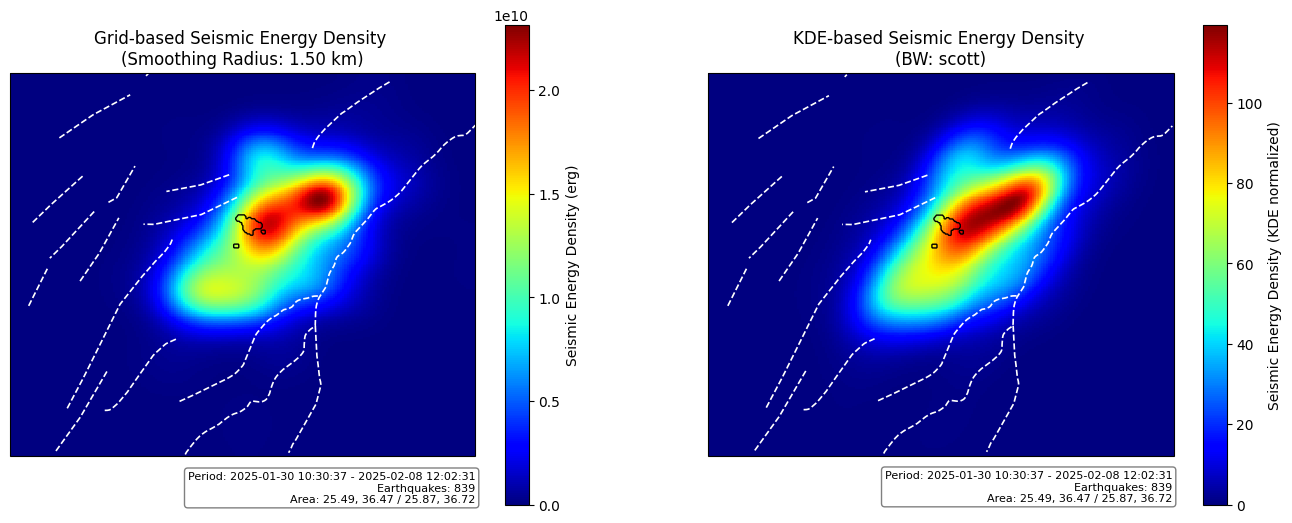

In [18]:
%%capture_and_save_html
print("\n")
print(f"**Seismic Energy Density (Grid-based & KDE-based) with Clipped NOA Faults**")

from math import radians, sin, cos, sqrt, atan2

def haversine(lon1, lat1, lon2, lat2):
    """
    Υπολογισμός της σφαιρικής απόστασης μεταξύ δύο σημείων με τον νόμο του Haversine.
    Οι συντεταγμένες δίνονται σε μοίρες.
    Επιστρέφει την απόσταση σε χιλιόμετρα.
    """
    R = 6371.0  # Ακτίνα της Γης σε km

    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

# ✅ Ζητάμε από τον χρήστη το bandwidth για το KDE
bw_input = input("Enter bandwidth for KDE (0-1, 'scott', or 'silverman'): ")
bw_method = bw_input if bw_input in ['scott', 'silverman'] else float(bw_input)

# ✅ Ζητάμε από τον χρήστη το smoothing radius σε km
smoothing_radius_km = float(input("Enter Gaussian smoothing radius in km (e.g., 0.5 - 20): "))

# ✅ Φόρτωση δεδομένων σεισμών
lons = df_35day["Longitude"].values
lats = df_35day["Latitude"].values
energies = df_35day["Seismic Energy"].values  # Seismic Energy σε erg

# ✅ Φόρτωση ρηγμάτων από το αρχείο NOA Faults
faults_file = "/content/NOAFaults_v6.0.gmt.csv"

# ✅ Υπολογισμός ορίων της περιοχής ενδιαφέροντος
min_lon, max_lon = lons.min(), lons.max()
min_lat, max_lat = lats.min(), lats.max()

# ✅ Ανάγνωση του αρχείου γραμμών και φιλτράρισμα των ρηγμάτων στην περιοχή ενδιαφέροντος
faults = []

with open(faults_file, "r") as file:
    current_fault = []
    for line in file:
        line = line.strip()
        if line == ">" and current_fault:
            # ✅ Φιλτράρουμε μόνο τα σημεία εντός της περιοχής των σεισμικών δεδομένων
            clipped_fault = [
                (lon, lat) for lon, lat in current_fault
                if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat
            ]
            if len(clipped_fault) > 1:  # Αποθήκευση μόνο αν υπάρχουν τουλάχιστον 2 σημεία
                faults.append(LineString(clipped_fault))
            current_fault = []
        else:
            parts = line.split()
            if len(parts) == 3:  # Πρέπει να έχει 3 στοιχεία (Lon, Lat, Fault_ID)
                lon, lat = map(float, parts[:2])
                current_fault.append((lon, lat))

    # ✅ Προσθήκη του τελευταίου ρήγματος (αν υπάρχει και είναι εντός των ορίων)
    if current_fault:
        clipped_fault = [
            (lon, lat) for lon, lat in current_fault
            if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat
        ]
        if len(clipped_fault) > 1:
            faults.append(LineString(clipped_fault))

# ✅ Μετατροπή των ρηγμάτων σε GeoDataFrame
faults_gdf = gpd.GeoDataFrame(geometry=faults, crs="EPSG:4326")

# ✅ Ορισμός του Grid
num_bins = 200  # Διαστάσεις grid (200x200)
lon_bins = np.linspace(lons.min(), lons.max(), num_bins)
lat_bins = np.linspace(lats.min(), lats.max(), num_bins)

# ✅ Υπολογισμός μεγέθους κελιού σε km
Xcell_size_inkm = haversine(lon_bins[0], lat_bins[0], lon_bins[1], lat_bins[0])  # Απόσταση μεταξύ διαδοχικών Lon
Ycell_size_inkm = haversine(lon_bins[0], lat_bins[0], lon_bins[0], lat_bins[1])  # Απόσταση μεταξύ διαδοχικών Lat

# ✅ Υπολογισμός του sigma με βάση το smoothing radius που έδωσε ο χρήστης
sigma = smoothing_radius_km / ((Xcell_size_inkm + Ycell_size_inkm) / 2)

# ✅ Υπολογισμός αθροιστικής σεισμικής ενέργειας σε κάθε κελί (grid-based)
energy_grid, _, _ = np.histogram2d(lats, lons, bins=[lat_bins, lon_bins], weights=energies)

# ✅ Εφαρμογή Gaussian smoothing με το υπολογισμένο sigma
energy_grid = gaussian_filter(energy_grid, sigma=sigma)

# ✅ Υπολογισμός KDE για σεισμική ενέργεια (Energy in erg)
xy = np.vstack([lons, lats])
kde_energy = gaussian_kde(xy, bw_method=bw_method, weights=energies)

# ✅ Δημιουργία κανονικού πλέγματος (για KDE)
grid_lon, grid_lat = np.meshgrid(lon_bins, lat_bins)
density_energy = kde_energy(np.vstack([grid_lon.ravel(), grid_lat.ravel()]))
density_energy = density_energy.reshape(grid_lon.shape)

# ✅ Δημιουργία Χαρτών
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Υπολογισμός περιόδου δεδομένων και αριθμού σεισμών
date_from = pd.to_datetime(df_35day['Origin Time (GMT)']).min().strftime('%Y-%m-%d %H:%M:%S')
date_to = pd.to_datetime(df_35day['Origin Time (GMT)']).max().strftime('%Y-%m-%d %H:%M:%S')
earthquake_count = len(df_35day)

lons_min, lons_max = df_35day["Longitude"].min(), df_35day["Longitude"].max()
lats_min, lats_max = df_35day["Latitude"].min(), df_35day["Latitude"].max()


# ======= 1ος Χάρτης: Grid-based Seismic Energy Density =======
ax1 = axes[0]
mesh1 = ax1.pcolormesh(grid_lon, grid_lat, energy_grid, cmap="jet", shading="auto", transform=ccrs.PlateCarree())
ax1.add_geometries(coastline.geometry, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1)
faults_gdf.plot(ax=ax1, color="white", linestyle="--", linewidth=1.2, label="NOA Faults")
plt.colorbar(mesh1, ax=ax1, label="Seismic Energy Density (erg)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title(f"Grid-based Seismic Energy Density \n(Smoothing Radius: {smoothing_radius_km:.2f} km)")
# Προσθήκη υπομνήματος κάτω δεξιά
ax1.text(
    lons_min + (lons_max - lons_min) , lats_min - 0.01,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='top', bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)


# ======= 2ος Χάρτης: KDE-based Seismic Energy Density =======
ax2 = axes[1]
mesh2 = ax2.pcolormesh(grid_lon, grid_lat, density_energy, cmap="jet", shading="auto", transform=ccrs.PlateCarree())
ax2.add_geometries(coastline.geometry, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1)
faults_gdf.plot(ax=ax2, color="white", linestyle="--", linewidth=1.2, label="NOA Faults")
plt.colorbar(mesh2, ax=ax2, label="Seismic Energy Density (KDE normalized)")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title(f"KDE-based Seismic Energy Density \n(BW: {bw_method})")
# Προσθήκη υπομνήματος κάτω δεξιά
ax2.text(
    lons_min + (lons_max - lons_min) , lats_min - 0.01,
    f"Period: {date_from} - {date_to}\nEarthquakes: {earthquake_count}\nArea: {lons_min:.2f}, {lats_min:.2f} / {lons_max:.2f}, {lats_max:.2f}",
    fontsize=8, color='black', ha='right', va='top', bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

#plt.tight_layout()
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.2, hspace=0.2)
plt.show()


Enter the time window for grouping seismic events (e.g., '24h', '12h', '6h'): 24


**Weighted Mean Seismic Activity Trajectory with NOA Faults**

<ipython-input-19-5b8f88306afa>:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df_35day.groupby("Time Bin", group_keys=False).apply(




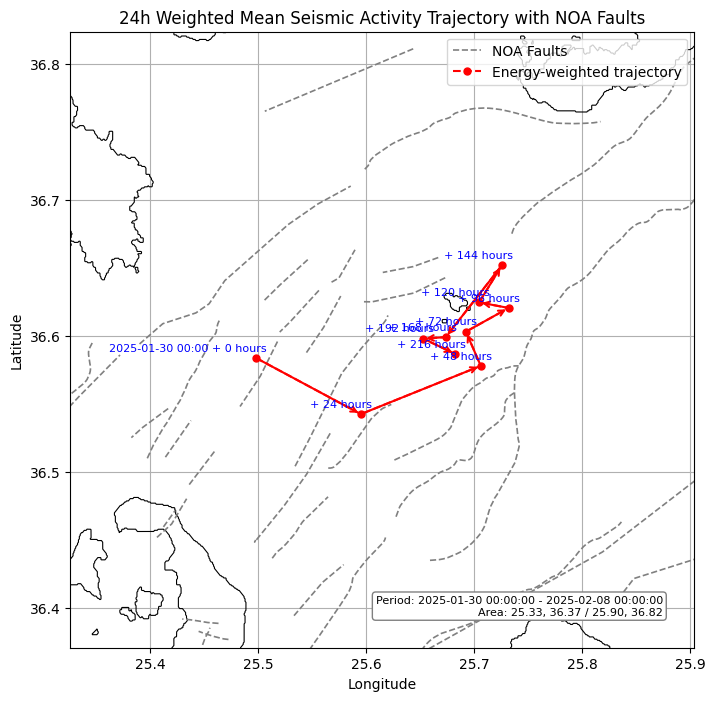

In [19]:
%%capture_and_save_html

print("\n")
print(f"**Weighted Mean Seismic Activity Trajectory with NOA Faults**")

# ✅ Ζητάμε από τον χρήστη το χρονικό παράθυρο και προσθέτουμε έλεγχο
time_window = input("Enter the time window for grouping seismic events (e.g., '24h', '12h', '6h'): ").strip()

# ✅ Έλεγχος αν ο χρήστης εισήγαγε μόνο αριθμό χωρίς μονάδα (π.χ. "24" αντί για "24h")
if time_window.isdigit():
    time_window += "h"  # Προσθέτουμε μονάδα ωρών αν λείπει

# ✅ Έλεγχος εγκυρότητας
try:
    pd.to_timedelta(time_window)  # Δοκιμάζουμε αν είναι έγκυρο offset
except ValueError:
    raise ValueError(f"❌ Invalid input: '{time_window}' is not a valid time window. Use format like '24h', '12h', '6h', etc.")

# ✅ Εφαρμόζουμε ομαδοποίηση
df_35day["Time Bin"] = df_35day["Origin Time (GMT)"].dt.floor(time_window)


# ✅ Ομαδοποίηση σεισμών ανά χρονικό παράθυρο και υπολογισμός του κέντρου βάρους της ενέργειας
df_35day["Time Bin"] = df_35day["Origin Time (GMT)"].dt.floor(time_window)

grouped = df_35day.groupby("Time Bin", group_keys=False).apply(
    lambda g: pd.Series({
        "Weighted Lat": np.average(g["Latitude"], weights=g["Seismic Energy"]),
        "Weighted Lon": np.average(g["Longitude"], weights=g["Seismic Energy"]),
        "Date": g["Time Bin"].iloc[0].strftime("%Y-%m-%d %H:%M")  # ✅ Προσθήκη ημερομηνίας ως string
    })
).reset_index()

# ✅ Δημιουργία γεωμετρικών αντικειμένων
grouped["geometry"] = grouped.apply(lambda row: Point(row["Weighted Lon"], row["Weighted Lat"]), axis=1)
trajectory = LineString(grouped["geometry"].values)

# ✅ Ορισμός γεωγραφικών ορίων για την περιοχή
padding_factor = 1
padding_lon = (grouped["Weighted Lon"].max() - grouped["Weighted Lon"].min())
padding_lat = (grouped["Weighted Lat"].max() - grouped["Weighted Lat"].min())
padding = padding_factor * (padding_lon + padding_lat) / 2

# Νέα γεωγραφικά όρια
min_lon = grouped["Weighted Lon"].min() - padding
max_lon = grouped["Weighted Lon"].max() + padding
min_lat = grouped["Weighted Lat"].min() - padding
max_lat = grouped["Weighted Lat"].max() + padding

# ======= Ανάγνωση και σχεδίαση ρηγμάτων =======
faults_file = "/content/NOAFaults_v6.0.gmt.csv"
faults = []

# Ανάγνωση του αρχείου γραμμών
with open(faults_file, "r") as file:
    current_fault = []
    for line in file:
        line = line.strip()
        if line == ">" and current_fault:
            faults.append(LineString(current_fault))  # Αποθήκευση προηγούμενου ρήγματος
            current_fault = []
        else:
            parts = line.split()
            if len(parts) == 3:  # Πρέπει να έχει 3 στοιχεία (Lon, Lat, Fault_ID)
                lon, lat = map(float, parts[:2])
                current_fault.append((lon, lat))
    if current_fault:
        faults.append(LineString(current_fault))

# Μετατροπή των ρηγμάτων σε GeoDataFrame
faults_gdf = gpd.GeoDataFrame(geometry=faults, crs="EPSG:4326")

# ======= Σχεδίαση τροχιάς =======
fig, ax = plt.subplots(figsize=(10, 8))

# ✅ Σχεδίαση ακτογραμμών
coastline = gpd.read_file(coastline_shp)
coastline.boundary.plot(ax=ax, color="black", linewidth=0.8)

# ✅ Σχεδίαση ρηγμάτων
faults_gdf.plot(ax=ax, color="gray", linewidth=1.2, linestyle="--", label="NOA Faults")

# ✅ Ορισμός γεωγραφικών ορίων στον χάρτη
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

# ✅ Σχεδίαση τροχιάς με βελάκια
x, y = grouped["Weighted Lon"].values, grouped["Weighted Lat"].values
ax.plot(x, y, linestyle="--", color="red", linewidth=1.5, marker="o", markersize=5, label="Energy-weighted trajectory")
for i in range(len(x) - 1):
    ax.annotate("", xy=(x[i + 1], y[i + 1]), xytext=(x[i], y[i]),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

# ✅ Προσθήκη χρονικών ετικετών με μετατόπιση
t0 = pd.to_datetime(grouped.iloc[0]["Time Bin"])  # Χρόνος πρώτου σημείου
for idx, row in grouped.iterrows():
    t_current = pd.to_datetime(row["Time Bin"])
    delta_hours = (t_current - t0).total_seconds() / 3600  # Διαφορά σε ώρες

    # ✅ Το πρώτο σημείο δείχνει την ημερομηνία + 0 ώρες
    if idx == 0:
        label_text = f"{row['Date']} + 0 hours"
    else:
        label_text = f"+ {int(delta_hours)} hours"

    # Προσθήκη με μετατόπιση για αποφυγή επικάλυψης
    offset_x, offset_y = 0.01, 0.005
    ax.text(row["Weighted Lon"] + offset_x, row["Weighted Lat"] + offset_y, label_text,
            fontsize=8, ha='right', color='blue')

# ✅ Προσθήκη υπομνήματος και τίτλου
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{time_window} Weighted Mean Seismic Activity Trajectory with NOA Faults")
plt.legend()
plt.grid()

# ✅ Προσθήκη πληροφοριών περιόδου και περιοχής
date_from = grouped["Time Bin"].min().strftime('%Y-%m-%d %H:%M:%S')
date_to = grouped["Time Bin"].max().strftime('%Y-%m-%d %H:%M:%S')
ax.text(
    0.95, 0.05,
    f"Period: {date_from} - {date_to}\nArea: {min_lon:.2f}, {min_lat:.2f} / {max_lon:.2f}, {max_lat:.2f}",
    fontsize=8, color='black', ha='right', va='bottom', transform=ax.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

plt.show()


Enter filter width value in hours (e.g., 6): 48
Enter filter type (e.g., 'g' for Gaussian, or 'b' for Boxcar. More options at GMT reference manual): b


**Cumulative Seismic Energy and Seismic Energy Flow Rate**




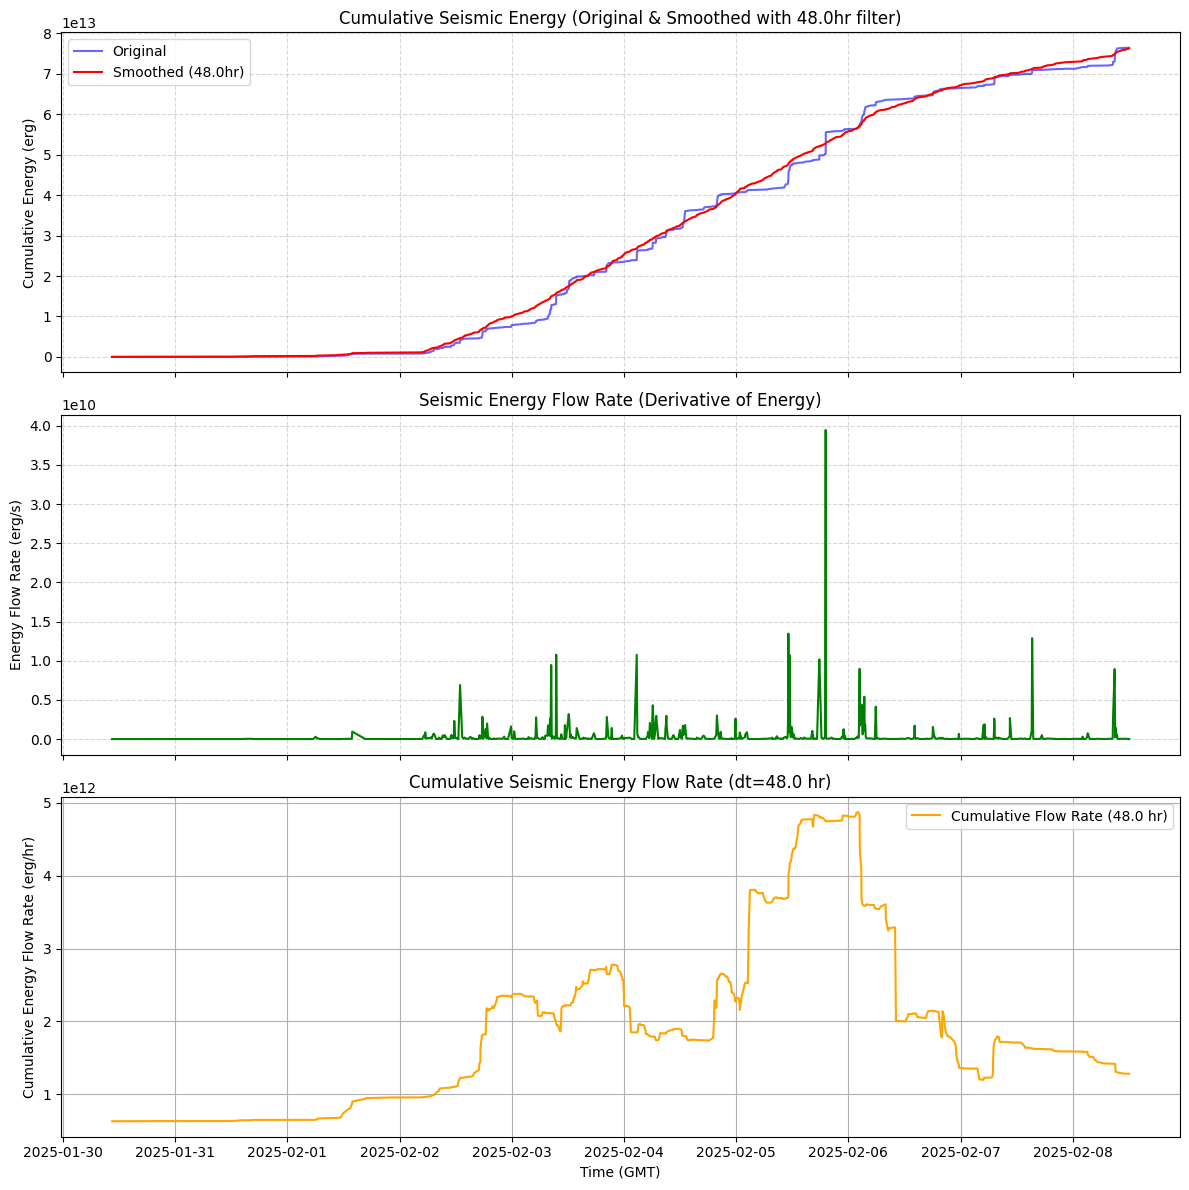

In [28]:
%%capture_and_save_html

print("\n")
print(f"**Cumulative Seismic Energy and Seismic Energy Flow Rate**")

# ✅ Ορισμός παραμέτρων
sigma_hours = float(input("Enter filter width value in hours (e.g., 6): "))
sigma_sec = sigma_hours * 3600  # Μετατροπή σε sec

# Επιλογή είδους φίλτρου
filter_type = input("Enter filter type (e.g., 'g' for Gaussian, or 'b' for Boxcar. More options at GMT reference manual): ")
filter_forgmt = f"{filter_type}{sigma_sec}"  # Δημιουργία συμβολοσειράς φίλτρου

# ✅ Φόρτωση σεισμικών δεδομένων
time = pd.to_datetime(df_35day["Origin Time (GMT)"]).astype(np.int64) // 10**9  # Μετατροπή σε UNIX timestamp
energy = df_35day["Seismic Energy"].values  # Seismic Energy σε erg

# ✅ Δημιουργία DataFrame για PyGMT
data = pd.DataFrame({"time": time, "energy": energy})

# ✅ Εφαρμογή φίλτρου με PyGMT
filtered_data = pygmt.filter1d(
    data=data,
    filter_type=filter_forgmt,
    end=True,  # Συμπερίληψη των άκρων
    time_col=0  # Στήλη χρόνου
)

# ✅ Ενημέρωση ονομάτων στηλών για συμβατότητα
filtered_data.columns = ["time", "energy"]  # Αντικατάσταση αριθμητικών δεικτών με ονόματα στηλών

# ✅ Υπολογισμός αθροιστικής σεισμικής ενέργειας
cumulative_energy = np.cumsum(energy)

# ✅ Χρήση των φιλτραρισμένων δεδομένων
cumulative_energy_smoothed = np.cumsum(filtered_data["energy"])

# ✅ Υπολογισμός **Seismic Energy Flow Rate (Derivative of Energy)**
energy_flow_rate = np.gradient(cumulative_energy, time)  # Παράγωγος της πραγματικής σεισμικής ενέργειας

# ✅ Υπολογισμός cumulative energy flow rate (erg/hr)
dt = int(sigma_sec / np.mean(np.diff(time)))  # Παράθυρο dt για κυλιόμενη μέση τιμή
window_size = dt if dt > 1 else 1  # Εξασφάλιση ότι το παράθυρο είναι θετικό

cumulative_flow_rate = np.convolve(energy_flow_rate, np.ones(window_size) / window_size, mode='same') * 3600

# ✅ Δημιουργία διαγραμμάτων
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 1. Αθροιστική Ενέργεια (Πρωτότυπη και Εξομαλυνμένη)
axes[0].plot(pd.to_datetime(time, unit='s'), cumulative_energy, label="Original", color="blue", alpha=0.6)
axes[0].plot(pd.to_datetime(time, unit='s'), cumulative_energy_smoothed, label=f'Smoothed ({sigma_hours:.1f}hr)', color="red")
axes[0].set_ylabel("Cumulative Energy (erg)")
axes[0].set_title(f"Cumulative Seismic Energy (Original & Smoothed with {sigma_hours:.1f}hr filter)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Ρυθμός ροής σεισμικής ενέργειας (χωρίς smoothing)
axes[1].plot(pd.to_datetime(time, unit='s'), energy_flow_rate, color="green")
axes[1].set_ylabel("Energy Flow Rate (erg/s)")
axes[1].set_title("Seismic Energy Flow Rate (Derivative of Energy)")
axes[1].grid(True, linestyle="--", alpha=0.5)

# 3. Cumulative Seismic Energy Flow Rate
axes[2].plot(pd.to_datetime(time, unit='s'), cumulative_flow_rate, color='orange', label=f'Cumulative Flow Rate ({sigma_hours:.1f} hr)')
axes[2].set_ylabel("Cumulative Energy Flow Rate (erg/hr)")
axes[2].set_title(f"Cumulative Seismic Energy Flow Rate (dt={sigma_hours:.1f} hr)")
axes[2].grid(True)
axes[2].legend()

# Ρυθμίσεις κοινού άξονα Χ
axes[2].set_xlabel("Time (GMT)")
plt.tight_layout()
plt.show()


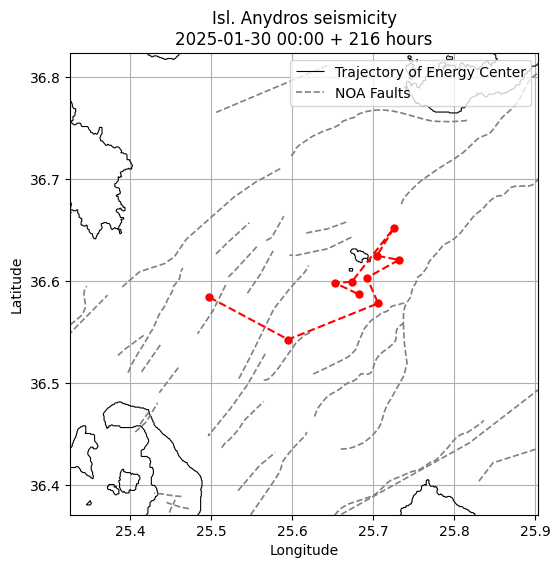

In [21]:

# ✅ Δημιουργία Animation
fig, ax = plt.subplots(figsize=(8, 6))

# ✅ Σχεδίαση ολόκληρης της ακτογραμμής
coastline = gpd.read_file(coastline_shp)
coastline.boundary.plot(ax=ax, color="black", linewidth=0.8)

# ✅ Σχεδίαση των ρηγμάτων
faults_gdf.plot(ax=ax, color="gray", linewidth=1.2, linestyle="--", label="NOA Faults")

# ✅ Ορισμός γεωγραφικών ορίων στον χάρτη
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

# ✅ Σχεδίαση κενής τροχιάς
line, = ax.plot([], [], linestyle="--", color="red", linewidth=1.5, marker="o", markersize=5)

# ✅ Προετοιμασία τίτλου animation
title_text = ax.set_title(f"{time_window} Weighted Mean Seismic Activity Trajectory")

# ✅ Χρονικό σημείο αναφοράς (πρώτος σεισμός)
t0 = pd.to_datetime(grouped.iloc[0]["Time Bin"])

# ✅ Συναρτήσεις animation
def init():
    """ Αρχικοποιεί το animation (κενός χάρτης). """
    line.set_data([], [])
    title_text.set_text("Isl. Anydros seismicity")
    return line, title_text

def update(frame):
    """ Προσθέτει σημεία στην τροχιά σταδιακά. """
    x = grouped["Weighted Lon"].values[:frame + 1]
    y = grouped["Weighted Lat"].values[:frame + 1]

    # ✅ Ενημέρωση της τροχιάς στο animation
    line.set_data(x, y)

    # ✅ Υπολογισμός της χρονικής διαφοράς από το πρώτο σημείο
    t_current = pd.to_datetime(grouped.iloc[frame]["Time Bin"])
    delta_hours = (t_current - t0).total_seconds() / 3600  # Διαφορά σε ώρες

    # ✅ Δημιουργία τίτλου (πρώτο σημείο: ημερομηνία, μετά: + ώρες)
    if frame == 0:
        title_text.set_text(f"Isl. Anydros seismicity\n{grouped.iloc[0]['Date']} + 0 hours")
    else:
        title_text.set_text(f"Isl. Anydros seismicity\n{grouped.iloc[0]['Date']} + {int(delta_hours)} hours")

    return line, title_text

# ✅ Δημιουργία του animation
ani = animation.FuncAnimation(fig, update, frames=len(grouped), init_func=init, interval=1000, blit=True)

# ✅ Αποθήκευση ή προβολή
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(["Trajectory of Energy Center", "NOA Faults"])
plt.grid()

# Προβολή του animation στο notebook
from IPython.display import HTML
HTML(ani.to_jshtml())


In [22]:
%%capture_and_save_html
print("\n")
print(f"**Animation ready for download @ colab files**")

ani.save("trajectory_animation.mp4", writer="ffmpeg", fps=1)
ani.save("trajectory_animation.gif", fps=1, writer="pillow")




**Animation ready for download @ colab files**



In [23]:
from google.colab import files #Reimporting the module
files.download(html_file_path) #Calling the download function
files.download("trajectory_animation.gif")
files.download("trajectory_animation.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>